# Exam

> Data: **2023-07-25**
>
> Autore: **Luigi Malaguti**

##

---

## Parte 0: Il Dataset

Il datataset (preso e modificato da [Kaggle](https://www.kaggle.com/datasets/iamsouravbanerjee/data-science-salaries-2023)) contiene dati relativi a salari di persone che operano in ambito data science. Il separatore è il ";". L’obiettivo è quello di inferire il livello di esperienza (Experience Level).

Nota: Il file csv che si trova al [link](https://bit.ly/2023BDTAS).

### Imports

In [1]:
!curl -sLo dataset.csv "https://bit.ly/2023BDTAS"
# !unzip -o dataset.zip
# !mv file.csv dataset.csv
# FILE_ID = "file_id"
# !curl -sLo dataset.csv "https://drive.google.com/uc?export=download&id={FILE_ID}"

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

### Dataset

In [3]:
df = pd.read_csv("dataset.csv", sep=";")

#### Overview

In [4]:
df.head()

,Job Title,Employment Type,Experience Level,Expertise Level,Company Location,Salary in USD,Employee Residence,Company Size,Year
0,Machine Learning Manager,Full-Time,Senior,Expert,United States,129562,Germany,Large,2023
1,BI Data Analyst,Full-Time,Entry,Junior,Kenya,50000,Kenya,Small,2023
2,AI Engineer,Full-Time,Senior,Expert,United States,227850,United States,Medium,2023
3,AI Engineer,Full-Time,Senior,Expert,United States,180500,United States,Medium,2023
4,Data Analyst,Full-Time,Mid,Intermediate,United States,90000,United States,Medium,2023


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3470 entries, 0 to 3469
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Job Title           3470 non-null   object
 1   Employment Type     3470 non-null   object
 2   Experience Level    3470 non-null   object
 3   Expertise Level     3470 non-null   object
 4   Company Location    3470 non-null   object
 5   Salary in USD       3470 non-null   int64 
 6   Employee Residence  3470 non-null   object
 7   Company Size        3470 non-null   object
 8   Year                3470 non-null   int64 
dtypes: int64(2), object(7)
memory usage: 244.1+ KB


#### Instances

In [6]:
df.shape

(3470, 9)

#### Missing values

In [7]:
df.isnull().sum().sum()

np.int64(0)

#### Balancing

In [8]:
df["Experience Level"].value_counts()

,count
Experience Level,
Senior,2187
Mid,833
Entry,296
Executive,154


<Axes: >

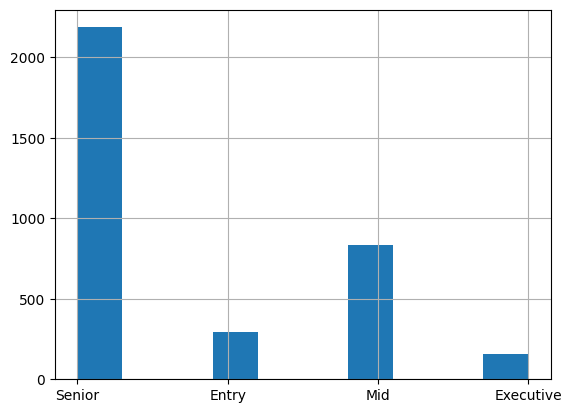

In [9]:
df["Experience Level"].hist()

##

---

## Parte 1: Analisi (Punti 10)

### Domanda 01 (Punti 2)

Quante sono le istanze contenute nel dataset? Il dataset è completo (cioè per ogni istanza tutti i valori di ogni attributo sono sempre correttamente specificati – non esistono "missing values")? Il dataset è bilanciato per quanto riguarda la classe da predire? Il livello di conoscenza (Expertise Level) è un attributo significativo nel determinare il livello di esperienza?

In [10]:
df.shape[0]

3470

> Il dataset contiene 3470 istanze.

In [11]:
df.isnull().sum().sum()

np.int64(0)

> Si, il dataset risulta completo, in quanto non sono presenti missing values.

In [12]:
df["Experience Level"].value_counts()

,count
Experience Level,
Senior,2187
Mid,833
Entry,296
Executive,154


> No, il dataset non risulta bilanciato, in quanto la classe `Senior` è quasi uguale alla somma di tutte le altre classi, ovvero di `Mid`, `Entry` e `Executive`.

In [13]:
table = df.pivot_table(index="Experience Level", columns="Expertise Level", values="Job Title", aggfunc="count")
order_index = ["Entry", "Mid", "Senior", "Executive"]
order_columns = ["Junior", "Intermediate", "Expert", "Director"]
table = table.reindex(index=order_index, columns=order_columns)
table

Expertise Level,Junior,Intermediate,Expert,Director
Experience Level,,,,
Entry,296.0,NaN,NaN,NaN
Mid,NaN,833.0,NaN,NaN
Senior,NaN,NaN,2187.0,NaN
Executive,NaN,NaN,NaN,154.0


> Si, il livello di conoscenza, `Expertise Level`, è un attributo significativo al fine di predire il livello di esperienza, `Experience Level`. Infatti possiamo notare come ci sia una corrispondenza 1-a-1 tra i valori di questi attributi, quindi l'attributo `Expertise Level` andrebbe rimosso dal dataset. Il motivo risiede nel fatto che questo attributo non da nessuna informazione aggiuntiva e associando a ogni classe da predire un singolo valore specifico, questo porterebbe creare dei pattern 1-a-1, inficiando la predizione.

---

### Domanda 02 (Punti 3)

Verificare se il salario medio varia rispetto alla dimensione dell’impresa ("Company Size"), sia nel complesso sia relativamente al livello di esperienza. Quanti sono i data scientist che non risiedono nella nazione della impresa per cui lavorano?

#### Verificare se il salario medio varia rispetto alla dimensione dell’impresa ("Company Size"), sia nel complesso sia relativamente al livello di esperienza. (Punti 2)

In [14]:
df.groupby("Company Size")["Salary in USD"].mean()

,Salary in USD
Company Size,
Large,118216.078603
Medium,149195.084295
Small,87487.189542


> Sembrerebbe che il salario medio dei dipendenti aumenti con la dimensione dell'azienda, seppur il salario medio più alto risulti essere per le aziende di medie dimensioni.

In [15]:
# table = df.pivot_table(index="Experience Level", columns="Company Size", values="Salary in USD", aggfunc="mean")
# SAME AS ABOVE
table = df.groupby(["Experience Level", "Company Size"])["Salary in USD"].mean().unstack()
table

Company Size,Large,Medium,Small
Experience Level,,,
Entry,76546.319149,84644.038217,68835.644444
Executive,181610.470588,190706.798450,169172.375000
Mid,91286.455172,116671.653543,68613.075472
Senior,151602.455446,162317.830237,112724.765957


In [16]:
table.mean()

,0
Company Size,
Large,125261.425089
Medium,138585.080112
Small,104836.465218


In [17]:
table.mean(axis=1)

,0
Experience Level,
Entry,76675.333937
Executive,180496.548013
Mid,92190.394729
Senior,142215.017213


> Anche considerando sia il livello di esperienza che la dimensione dell'azienda, il salario medio risulta essere maggiore per le aziende di medie-grandi dimensioni, con il picco sempre sulle medie dimensioni.
>
> Inoltre, il livello di esperienza presenta una crescita lineare con l'aumento dello stipendio medio, sempre considerando anche la dimensione aziendale.

#### Quanti sono i data scientist che non risiedono nella nazione della impresa per cui lavorano? (Punti 1)

In [18]:
mask_data_scientist = df["Job Title"] == "Data Scientist"
mask_different_location = df["Company Location"] != df["Employee Residence"]
df[mask_data_scientist & mask_different_location].shape[0]

20

> I dipendenti di ruolo `Data Scientist` che lavorano in una azienda con residenza differente da quella del dipendente sono 20.

---

### Domanda 03 (Punti 3)

Il salario ricevuto dai lavoratori (Salary in USD) è distribuito nello stesso modo nelle imprese di piccola, media e grande dimensione? Rappresentare con il/gli opportuni grafici il concetto. Il salario ha poi la stessa distribuzione all’interno dei livelli di esperienza?

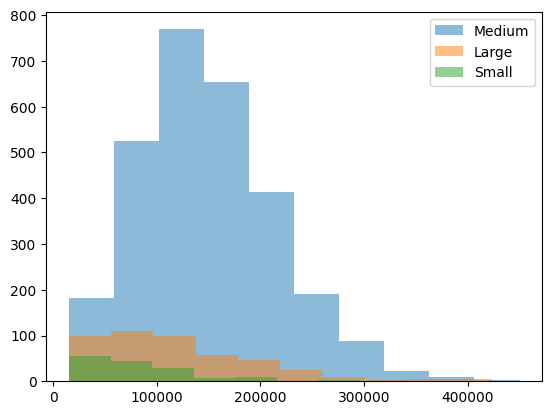

In [19]:
mask_small = df["Company Size"] == "Small"
mask_medium = df["Company Size"] == "Medium"
mask_large = df["Company Size"] == "Large"
plt.hist(df[mask_medium]["Salary in USD"], label="Medium", alpha=0.5)
plt.hist(df[mask_large]["Salary in USD"], label="Large", alpha=0.5)
plt.hist(df[mask_small]["Salary in USD"], label="Small", alpha=0.5)
plt.legend()
plt.show()

> Possiamo notare come le aziende di grandi e piccole dimensioni abbiano all'incirca la stessa distribuzione. Una zona iniziale più elevata, per poi andare a diminuire con l'aumento del salario. Mentre le aziende di medie dimensioni hanno una distribuzione più a campana, nel quale il picco massimo viene mostrato più al centro rispetto alle distribuzioni delle aziende piccole e grandi.

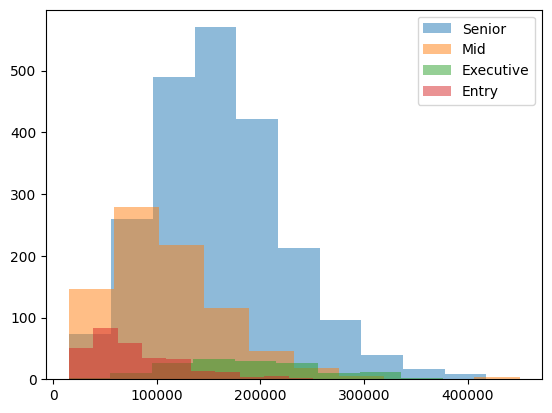

In [20]:
mask_entry = df["Experience Level"] == "Entry"
mask_mid = df["Experience Level"] == "Mid"
mask_senior = df["Experience Level"] == "Senior"
mask_executive = df["Experience Level"] == "Executive"
plt.hist(df[mask_senior]["Salary in USD"], label="Senior", alpha=0.5)
plt.hist(df[mask_mid]["Salary in USD"], label="Mid", alpha=0.5)
plt.hist(df[mask_executive]["Salary in USD"], label="Executive", alpha=0.5)
plt.hist(df[mask_entry]["Salary in USD"], label="Entry", alpha=0.5)
plt.legend()
plt.show()

> La distribuzione salariale rispetto al livello di esperienza è abbastanza simile per i livelli senior ed esecutivi. Le distribuzioni dei salari per i livelli medi ed entry, invece, presentano una distribuzione sulla riga dei livelli senior, ma con una inclinazione sempre maggiore verso i salari più bassi man mano che il livello diminuisce.

---

### Domanda 04 (Punti 2)

Quali sono i 5 lavori (Job Title) più remunerativi?

In [21]:
df.groupby("Job Title")["Salary in USD"].mean().sort_values(ascending=False).head(5)

,Salary in USD
Job Title,
Analytics Engineering Manager,399880.0
Data Science Tech Lead,375000.0
Managing Director Data Science,300000.0
AWS Data Architect,258000.0
Cloud Data Architect,250000.0


##

---

## Parte 2: Trasformazione e Predizione (Punti 20)

### Domanda 01 (Punti 3)

Si vuole predire il valore di Experience Level sulla base degli attributi presenti nel dataset. Ricaricare il dataset originale, eliminare eventuali attributi inutili (giustificare la scelta), eliminare le istanze che eventualmente contengono valori nulli, rendere tutti gli attributi numerici utilizzando un ordinal encoder, e dividerlo in modo che 3/4 degli elementi siano contenuti in un nuovo dataset "train" e 1/4 nel dataset "test".

Allenare il train con il modello Decision Tree e valutare l’accuracy ottenuta calcolata sia sul dataset train sia sul dataset test. Confrontare i risultati ottenuti con quelli ottenuti con una predizione basata sul modello KNeighborsClassifier. Effettuare alcune considerazioni sui risultati ottenuti, tenendo in considerazione anche l’analisi della confusion matrix e la predizione effettuata da un dummy classifier.

In [22]:
df = pd.read_csv("dataset.csv", sep=";")
df.drop("Expertise Level", axis=1, inplace=True)
df.dropna(inplace=True)
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=int)
categorical_columns = df.select_dtypes(include="object").columns
df[categorical_columns] = encoder.fit_transform(df[categorical_columns])
df

,Job Title,Employment Type,Experience Level,Company Location,Salary in USD,Employee Residence,Company Size,Year
0,89,2,3,70,129562,29,0,2023
1,16,2,0,38,50000,44,2,2023
2,2,2,3,70,227850,80,1,2023
3,2,2,3,70,180500,80,1,2023
4,33,2,2,70,90000,80,1,2023
...,...,...,...,...,...,...,...,...
3465,61,2,3,70,412000,80,0,2020
3466,104,2,2,70,151000,80,0,2021
3467,61,2,0,70,105000,80,2,2020
3468,21,0,0,70,100000,80,0,2020


In [23]:
X, y = df.drop("Experience Level", axis=1), df["Experience Level"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

DecisionTree:
TRAIN
    Accuracy: 0.9377401998462721
    F1 Score: 0.9392652124308472


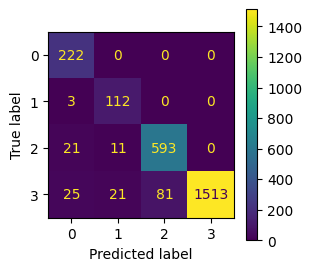

------------------------------
TEST
    Accuracy: 0.5207373271889401
    F1 Score: 0.5342603673790356


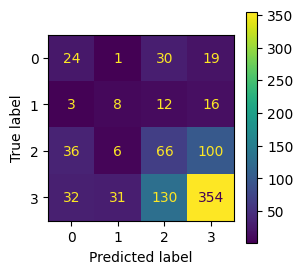


KNeighbors:
TRAIN
    Accuracy: 0.7213681783243658
    F1 Score: 0.7072203844945816


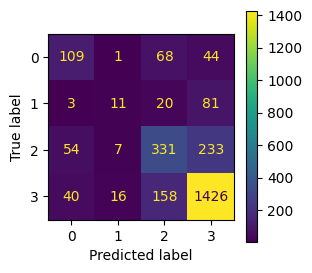

------------------------------
TEST
    Accuracy: 0.6152073732718893
    F1 Score: 0.5993961705802457


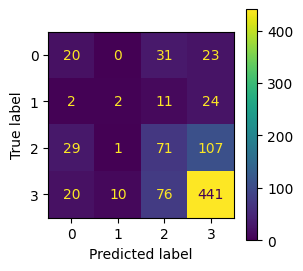


Dummy:
TRAIN
    Accuracy: 0.6302843966179862
    F1 Score: 0.48734861407519914


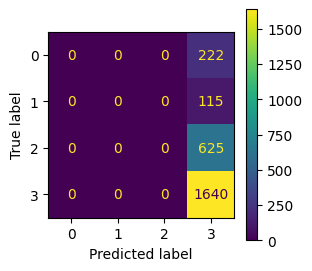

------------------------------
TEST
    Accuracy: 0.630184331797235
    F1 Score: 0.48722378726938165


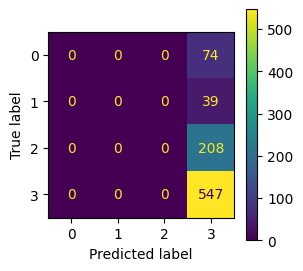

In [24]:
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=0),
    "KNeighbors": KNeighborsClassifier(),
    "Dummy": DummyClassifier(strategy="most_frequent", random_state=0)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(f"{name}:")
    print("=" * 30)
    print("TRAIN")
    print("    Accuracy:", accuracy_score(y_train, y_pred_train))
    print("    F1 Score:", f1_score(y_train, y_pred_train, average="weighted"))
    display = ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train))
    fig, ax = plt.subplots(figsize=(3, 3))
    display.plot(ax=ax)
    plt.show()
    print("-" * 30)
    print("TEST")
    print("    Accuracy:", accuracy_score(y_test, y_pred_test))
    print("    F1 Score:", f1_score(y_test, y_pred_test, average="weighted"))
    display = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test))
    fig, ax = plt.subplots(figsize=(3, 3))
    display.plot(ax=ax)
    plt.show()
    print("=" * 30)
    print()

> I modelli non mostrano performance troppo buone. Il modello che sembra predire meglio è il `KNeighbors` con una accuracy del 61% sul dataset di test, il ché non è molto buono. Dalla confusion matrix possiamo notare come il motivo principale di queste performance scadenti siano le classi 2 e 3, ovvero `Mid` e `Senior`, le quali vengono predette principalmente come classi 0 e 1, `Entry` ed `Executive`. Sempre a queste classi possiamo attribuirne il miglioramento delle performance del `KNeighbors` rispetto il `DecisionTree`. Infatti, quest'ultimo effettua maggiori errori su queste classi rispetto al modello `KNeighbors`. Il modello `Dummy` ha la strategia di predire sempre la classe più frequente, come è possibile vedere dalla confusion matrix, il quale predice sempre la classe 3, `Senior`. Questo modello porta inevitabilmente ad effettuare molti errori, quindi le performance vanno di conseguenza.

---

### Domanda 02 (Punti 4)

Trovare i parametri migliori del classificatore DecisionTree. Agire sui parametri criterion e min_samples_leaf. Verificare se l’accuratezza che si ottiene con la nuova configurazione supera quella con i parametri di default ottenuta al punto 1.

Best params: {'criterion': 'entropy', 'min_samples_leaf': 10}
Best score: 0.6556489000442934
Accuracy: 0.6440092165898618
F1 Score: 0.6181558907644533


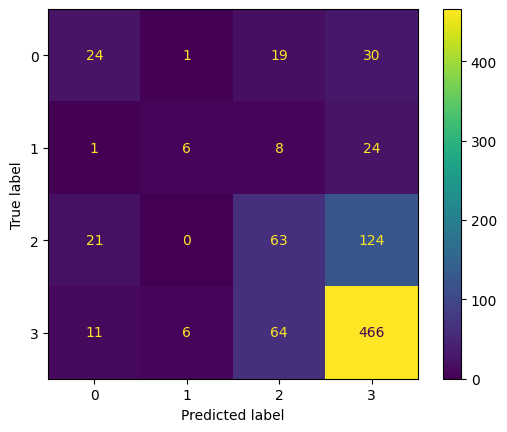

In [25]:
decision_tree = models["DecisionTree"]

params = {
    "criterion": ["gini", "entropy", "log_loss"],
    "min_samples_leaf": [1, 2, 5, 10],
}
grid_search = GridSearchCV(
    estimator=decision_tree,
    param_grid=params,
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

> Applicando il `GridSearchCV` al modello `DecisionTree` siamo stati in grado di trovare i parametri ottimali per `criterion` e `min_samples_leaf`, rispettivamente `entropy` e `10`.
>
> Questi parametri ottimali hanno portato ad un incremento dell'accuratezza del modello e attraverso la confusion matrix possiamo notare che ha colmato in parte gli errori di predizione per le classi 2 e 3.

---

### Domanda 03 (Punti 4)

Creare una pipeline che a partire dal dataset numerico utilizzato nel punto 1 applichi:

- il SimpleImputer per sostituire eventuali valori nulli
- divida in 10 bins i valori di Salary in USD
- applichi il DecisionTreeClassifier per effettuare la predizione

In [26]:
df = pd.read_csv("dataset.csv", sep=";")
df.drop("Expertise Level", axis=1, inplace=True)
df.dropna(inplace=True)
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=int)
categorical_columns = df.select_dtypes(include="object").columns
df[categorical_columns] = encoder.fit_transform(df[categorical_columns])

In [27]:
X, y = df.drop("Experience Level", axis=1), df["Experience Level"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [28]:
discretizer = KBinsDiscretizer(n_bins=10, random_state=0)

column_transformer = ColumnTransformer(
    transformers=[
        ("discretizer", discretizer, [X.columns.get_loc("Salary in USD")]),
    ],
    remainder="passthrough",
)
column_transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('discretizer',
                                 KBinsDiscretizer(n_bins=10, random_state=0),
                                 [3])])

In [29]:
best_criterion = grid_search.best_params_["criterion"]
best_min_samples_leaf = grid_search.best_params_["min_samples_leaf"]
decision_tree = DecisionTreeClassifier(criterion=best_criterion, min_samples_leaf=best_min_samples_leaf, random_state=0)
imputer = SimpleImputer(strategy="most_frequent")

pipeline = Pipeline(
    steps=[
        ("imputer", imputer),
        ("column_transformer", column_transformer),
        ("decision_tree", decision_tree),
    ],
)
pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('column_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('discretizer',
                                                  KBinsDiscretizer(n_bins=10,
                                                                   random_state=0),
                                                  [3])])),
                ('decision_tree',
                 DecisionTreeClassifier(criterion='entropy',
                                        min_samples_leaf=10, random_state=0))])

Accuracy: 0.6405529953917051
F1 Score: 0.6029573849264679


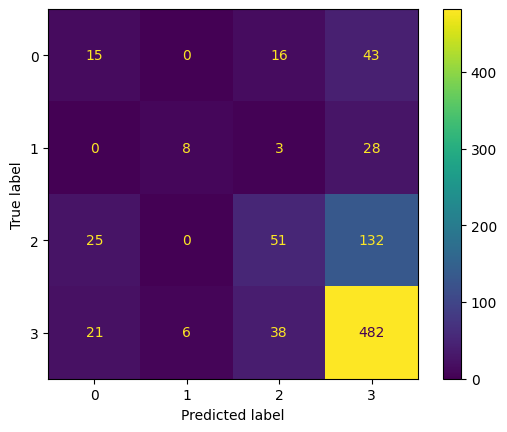

In [30]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

> Le performance di questa pipeline risultano essere simili a quelle viste nel punto precedente, ma maggiori a quelle iniziali, come detto anche precedentemente.

---

### Domanda 04 (Punti 1)

Estendere la pipeline del punto precedente aggiungendo a ogni feature una nuova feature che rappresenti il valore della feature normalizzato. Applicare il DecisionTreeClassifier per effettuare la predizione.

In [31]:
scaler = StandardScaler()
function_transformer = FunctionTransformer(lambda column: column)

feature_union = FeatureUnion(
    transformer_list=[
        ("scaler", scaler),
        ("function_transformer", function_transformer),
    ],
)
feature_union

FeatureUnion(transformer_list=[('scaler', StandardScaler()),
                               ('function_transformer',
                                FunctionTransformer(func=<function <lambda> at 0x780ebb864360>))])

In [32]:
pipeline = Pipeline(
    steps=[
        ("imputer", imputer),
        ("column_transformer", column_transformer),
        ("feature_union", feature_union),
        ("decision_tree", decision_tree),
    ],
)
pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('column_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('discretizer',
                                                  KBinsDiscretizer(n_bins=10,
                                                                   random_state=0),
                                                  [3])])),
                ('feature_union',
                 FeatureUnion(transformer_list=[('scaler', StandardScaler()),
                                                ('function_transformer',
                                                 FunctionTransformer(func=<function <lambda> at 0x780ebb864360>))])),
                ('decision_tree',
                 DecisionTreeClassifier(criterion='entropy',
                                        min_samples_leaf=10, random_state=0))])

Accuracy: 0.6405529953917051
F1 Score: 0.6029573849264679


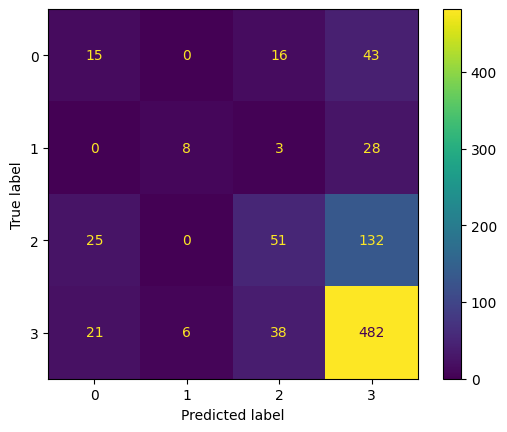

In [33]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

> Analogo alla pipeline precedente.

---

### Domanda 05 (Punti 6)

Creare una pipeline che a partire dal dataset iniziale (dopo aver tolto le colonne rimosse al punto 1):

- usi il SimpleImputer per inserire i valori nulli
- trasformi in vettori booleani (OneHotEncoder, sparse_output=False) le colonne 'Job Title', 'Employment Type', 'Company Location', 'Employee Residence'
- trasformi in valori numerici le colonne 'Year', 'Company Size'
- Applichi lo standard scaler sulla colonna Salary in USD
- applichi il DecisionTreeClassifier per effettuare la predizione

In [34]:
df = pd.read_csv("dataset.csv", sep=";")
df.drop("Expertise Level", axis=1, inplace=True)
df.dropna(inplace=True)

In [35]:
X, y = df.drop("Experience Level", axis=1), df["Experience Level"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [36]:
one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ordinal = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=int)
scaler = StandardScaler()

column_transformer = ColumnTransformer(
    transformers=[
        ("one_hot", one_hot, X.columns.get_indexer(["Job Title", "Employment Type", "Company Location", "Employee Residence"])),
        ("ordinal", ordinal, X.columns.get_indexer(["Year", "Company Size"])),
        ("scaler", scaler, X.columns.get_indexer(["Salary in USD"])),
    ],
    remainder="passthrough",
    force_int_remainder_cols=False,
)
column_transformer

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('one_hot',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 array([0, 1, 2, 4])),
                                ('ordinal',
                                 OrdinalEncoder(dtype=<class 'int'>,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 array([6, 5])),
                                ('scaler', StandardScaler(), array([3]))])

In [37]:
imputer = SimpleImputer(strategy="most_frequent")

pipeline = Pipeline(
    steps=[
        ("imputer", imputer),
        ("column_transformer", column_transformer),
        ("decision_tree", decision_tree),
    ],
)
pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('column_transformer',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('one_hot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  array([0, 1, 2, 4])),
                                                 ('ordinal',
                                                  OrdinalEncoder(dtype=<class 'int'>,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  array([6, 5])),
                                                 ('scaler', StandardScaler(),
                                                  array([3]))])),
                ('decision_tree',
                 DecisionTreeClassifier(criterion='entropy',
                                        min_samples_leaf=10, random_state=0))])

Accuracy: 0.6543778801843319
F1 Score: 0.6218657060988049


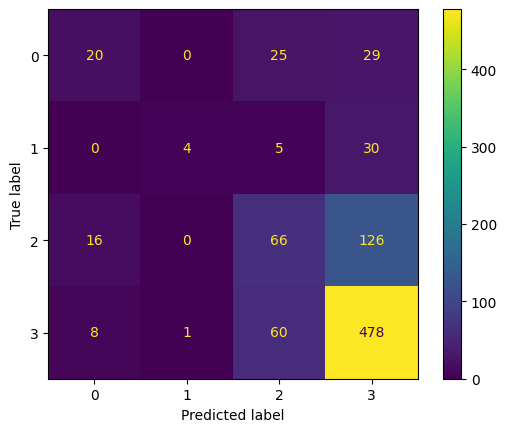

In [38]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

> Questa pipeline ottiene performance leggermente migliori rispetto ai punti precedenti, ma di un punto percentuale.

---

### Domanda 06 (Punti 2)

E’ possibile utilizzare un regressore linerare al posto del DecisionTree? In che modo?

In [44]:
df = pd.read_csv("dataset.csv", sep=";")
df.drop("Expertise Level", axis=1, inplace=True)
df.dropna(inplace=True)
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=int)
df["Experience Level"] = encoder.fit_transform(df[["Experience Level"]])

In [45]:
X, y = df.drop("Experience Level", axis=1), df["Experience Level"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [46]:
linear_regressor = LinearRegression()

pipeline = Pipeline(
    steps=[
        ("imputer", imputer),
        ("column_transformer", column_transformer),
        ("linear_regressor", linear_regressor),
    ],
)
pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('column_transformer',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('one_hot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  array([0, 1, 2, 4])),
                                                 ('ordinal',
                                                  OrdinalEncoder(dtype=<class 'int'>,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  array([6, 5])),
                                                 ('scaler', StandardScaler(),
                                                  array([3]))])),
                ('linear_regressor', LinearRegression())])

In [51]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test, y_pred))

RMSE: 0.8693733047279142
